<a href="https://colab.research.google.com/github/nazuna-0/WorkSheets_AshwiniTamang/blob/WorkSheet---6/WorkSheet6_AshwiniTamangipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Building and Testing Helper Function:**

1. Task To Do:

• Implement the Logistic Function by completing the code or writing your own function.

• Make sure you pass the test case.

In [ ]:
import numpy as np
def logistic_function(x):
# sigmoid formula
  y = 1/(1 + np.exp(-x))
  return y

Test Case for logistic function:

In [ ]:
import numpy as np
def test_logistic_function():
# Test with scalar input

  x_scalar = 0
  expected_output_scalar = round(1 / (1 + np.exp(0)), 3) # Expected output: 0.5
  assert round(logistic_function(x_scalar), 3) == expected_output_scalar, 'Test failed for scalar input'
  # Test with positive scalar input
  x_pos = 2
  expected_output_pos = round(1 / (1 + np.exp(-2)), 3) # Expected output: ~0.881
  assert round(logistic_function(x_pos), 3) == expected_output_pos, 'Test failed for positive scalar input'
  # Test with negative scalar input
  x_neg = -3
  expected_output_neg = round(1 / (1 + np.exp(3)), 3) # Expected output: ~0.047
  assert round(logistic_function(x_neg), 3) == expected_output_neg, 'Test failed for negative scalar input'


  # Test with numpy array input
  x_array = np.array([0, 2, -3])
  expected_output_array = np.array([0.5, 0.881, 0.047]) # Adjusted expected values rounded to 3 decimals
  # Use np.round to round the array element-wise and compare
  assert np.all(np.round(logistic_function(x_array), 3) == expected_output_array), 'Test failed for numpy array input'
  print("All tests passed!")

test_logistic_function()

All tests passed!


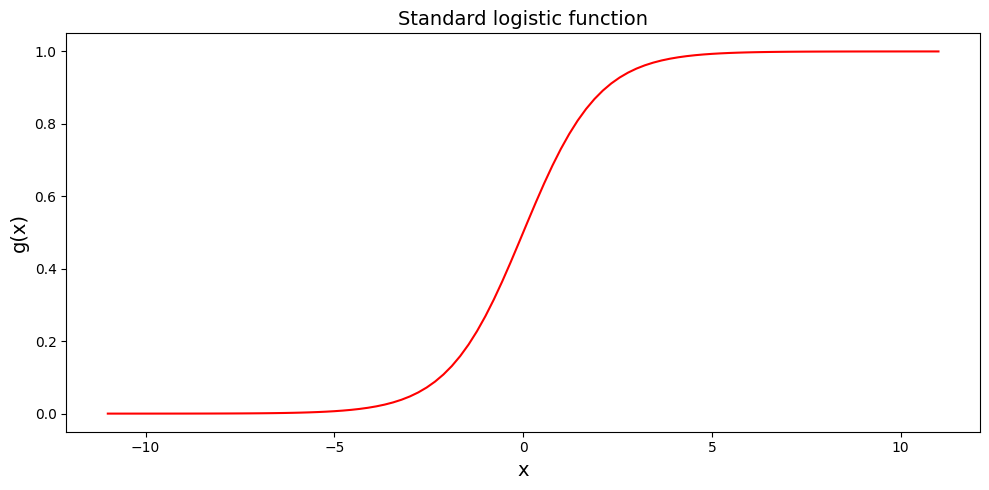

In [ ]:
# Plooting the sigmoid function:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize = (10, 5))
x = np.linspace(-11, 11, 100)
plt.plot(x, logistic_function(x), color = 'red')
plt.xlabel("x", fontsize = 14)
plt.ylabel("g(x)", fontsize = 14)
plt.title("Standard logistic function", fontsize = 14)
plt.tight_layout()
plt.show()

**2. Implementing Log Loss Function:**

Task To Do:

• Implement the Log - loss Function by completing the code or writing your own function.

• Make sure you pass the test case.

In [ ]:
def log_loss(y_true, y_pred):

# Ensure y_pred is clipped to avoid log(0)
  y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
  loss = -y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred)
  return loss

y_true, y_pred = 0, 0.1
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')
print("+++++++++++++--------------------------++++++++++++++++++++++++")
y_true, y_pred = 1, 0.9
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')


log loss(0, 0.1) ==> 0.10536051565782628
+++++++++++++--------------------------++++++++++++++++++++++++
log loss(1, 0.9) ==> 0.10536051565782628


In [ ]:
import numpy as np

def cost_function(y_true, y_pred):
    """
    Computes average log loss.
    """
    assert len(y_true) == len(y_pred), "Length mismatch"

    n = len(y_true)
    loss_vec = log_loss(y_true, y_pred)
    cost = np.sum(loss_vec) / n

    return cost

In [ ]:
def test_cost_function():
    y_true = np.array([1, 0, 1])
    y_pred = np.array([0.9, 0.1, 0.8])

    expected_cost = (-(np.log(0.9)) - np.log(0.9) - np.log(0.8)) / 3
    result = cost_function(y_true, y_pred)

    assert np.isclose(result, expected_cost, atol=1e-6)
    print("Test passed for cost function!")

test_cost_function()

Test passed for cost function!


In [ ]:
def costfunction_logreg(X, y, w, b):
    """
    Cost function for logistic regression
    """
    n, d = X.shape

    z = np.dot(X, w) + b
    y_pred = logistic_function(z)

    cost = cost_function(y, y_pred)
    return cost

In [ ]:
X = np.array([[10, 20], [-10, 10]])
y = np.array([1, 0])
w = np.array([0.5, 1.5])
b = 1

print("Cost:", costfunction_logreg(X, y, w, b))

Cost: 5.500008350834906


In [ ]:
def compute_gradient(X, y, w, b):
    """
    Computes gradients for logistic regression
    """
    n, d = X.shape

    z = np.dot(X, w) + b
    y_pred = logistic_function(z)

    grad_w = (1 / n) * np.dot(X.T, (y_pred - y))
    grad_b = (1 / n) * np.sum(y_pred - y)

    return grad_w, grad_b

In [ ]:
X = np.array([[10, 20], [-10, 10]])
y = np.array([1, 0])
w = np.array([0.5, 1.5])
b = 1

grad_w, grad_b = compute_gradient(X, y, w, b)
print("grad_w:", grad_w)
print("grad_b:", grad_b)

grad_w: [-4.99991649  4.99991649]
grad_b: 0.4999916492890759


In [ ]:
def gradient_descent(X, y, w, b, alpha, n_iter, show_cost=False, show_params=False):

    cost_history = []
    params_history = []

    for i in range(n_iter):
        grad_w, grad_b = compute_gradient(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        cost = costfunction_logreg(X, y, w, b)

        cost_history.append(cost)
        params_history.append((w.copy(), b))

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return w, b, cost_history, params_history

In [ ]:
X = np.array([[0.1, 0.2], [-0.1, 0.1]])
y = np.array([1, 0])
w = np.zeros(2)
b = 0.0

w_out, b_out, cost_history, _ = gradient_descent(
    X, y, w, b, alpha=0.1, n_iter=1000
)

print("Final w:", w_out)
print("Final b:", b_out)
print("Final cost:", cost_history[-1])

Final w: [4.30539485 2.10704574]
Final b: -0.30434456824754946
Final cost: 0.4606932714679932


In [ ]:
def prediction(X, w, b, threshold=0.5):
    z = np.dot(X, w) + b
    y_prob = logistic_function(z)
    y_pred = (y_prob >= threshold).astype(int)
    return y_pred

In [ ]:
X_test = np.array([[0.5, 1.0], [1.5, -0.5], [-0.5, -1.0]])
w_test = np.array([1.0, -1.0])
b_test = 0.0

print(prediction(X_test, w_test, b_test))

[0 1 1]


In [ ]:
def evaluate_classification(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    confusion_matrix = np.array([[TN, FP],
                                 [FN, TP]])

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return confusion_matrix, precision, recall, f1_score

=======================================

In [ ]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
z = np.array([[1, 2, 3]])
print(softmax(z))
print("Sum:", softmax(z).sum())

[[0.09003057 0.24472847 0.66524096]]
Sum: 0.9999999999999999


In [ ]:
def loss_softmax(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-10))

In [ ]:
y_true = np.array([0, 1, 0])
y_pred = np.array([0.1, 0.8, 0.1])
print(loss_softmax(y_true, y_pred))  # ≈ -log(0.8)

0.2231435511892097


In [ ]:
def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    cost = -np.sum(y * np.log(y_pred + 1e-10)) / n
    return cost

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W -= alpha * grad_W
        b -= alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

In [ ]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return cm, precision, recall, f1

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
num_features = X_train.shape[1]
num_classes = y_train.shape[1]

W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)

W, b, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha=0.1, n_iter=1000, show_cost=True
)

Iteration 0, Cost: 1.0068
Iteration 100, Cost: 0.3194
Iteration 200, Cost: 0.2514
Iteration 300, Cost: 0.2117
Iteration 400, Cost: 0.1850
Iteration 500, Cost: 0.1657
Iteration 600, Cost: 0.1512
Iteration 700, Cost: 0.1399
Iteration 800, Cost: 0.1308
Iteration 900, Cost: 0.1234


In [ ]:
y_test_pred = predict_softmax(X_test, W, b)
y_test_true = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_true, y_test_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1-score: 0.9333333333333333
